# Лабораторная работа №1: Детектирование объектов

## Цель
Познакомиться с современными методами детектирования объектов (YOLO, Faster R-CNN), научиться применять предобученные модели и дообучать их на собственных данных.

## Теория
- Object Detection: отличие от классификации и сегментации.
- Архитектуры: YOLO, SSD, Faster R-CNN.
- Метрики: IoU, mAP.

## Задания
1. Выберите одну из моделей (YOLOv8 или Faster R-CNN).
2. Загрузите предобученную модель и примените её к набору изображений (COCO subset, Pascal VOC или небольшой кастомный датасет).
3. Проведите fine-tuning на кастомном датасете (5–10 классов).
4. Оцените качество модели: постройте метрику mAP при разных IoU порогах.
5. Визуализируйте предсказания модели на тестовых изображениях.

## Вопросы
1. Чем one-stage детекторы отличаются от two-stage?
2. Какие ошибки чаще всего допускает модель при детекции?

## Требуемое содержание файла проекта
- Краткий обзор выбранной модели.
- Иллюстрации работы до и после дообучения.
- Графики/таблицы с результатами.
- Ответы на контрольные вопросы.

## Краткий обзор YOLOv8

YOLOv8 — современный one-stage детектор от Ultralytics (2023), продолжение серии YOLO.

- Детекция объектов, сегментация, классификация, pose estimation, tracking
- Несколько размеров моделей: nano (n), small (s), medium (m), large (l), extra-large (x)
- Высокая скорость инференса (до 80 FPS на GPU для nano-версии)
- Простое API для обучения и fine-tuning на кастомных датасетах
- Высокая точность при малых вычислительных затратах

### Особенности архитектуры
- PAN (Path Aggregation Network) + FPN для многомасштабного слияния признаков
- Anchor-free детекция предсказывает координаты рамок и классы объектов без использования заранее заданных шаблонов
- CIoU loss для bbox + BCE для классификации; DFL (Distribution Focal Loss) для точной локализации
- Искусственно изменяет изображения при обучении (поворот, масштаб, цвет) — модель становится устойчивее к разным условиям




## Ответы на вопросы

### 1. Чем one-stage детекторы отличаются от two-stage?

Two-stage детекторы (например, Faster R-CNN):
- Работают в два этапа:
  1. Region Proposal Network (RPN): предлагает области, где могут быть объекты
  2. Классификатор: уточняет границы и определяет класс для каждой области
- Преимущества: высокая точность, особенно для мелких объектов
- Недостатки: медленные (два прохода сети), сложнее обучать

One-stage детекторы (например, YOLOv8):
- Работают за один проход через сеть — сразу предсказывают координаты и классы
- Преимущества: очень быстрые (real-time детекция), проще в обучении
- Недостатки: исторически были менее точными для мелких объектов (но YOLOv8 сильно улучшил это)

Вывод: two-stage точнее, но медленнее; one-stage быстрее, подходят для real-time задач.


### 2. Какие ошибки чаще всего допускает модель при детекции?

По confusion matrix [после](runs/detect/val2/confusion_matrix_normalized.png) обучения можно выдвинуть следующее тезисы:
- Хуже всего модель распознает моотоциклы `motorcycle` — 35%, далее — `car` 42% и `truck` — 43%
- Хорошие результаты получились у `ambulance` и `bus` — 84% и 70% соответственно
- `ambulance` и `car` иногда распознается как `truck` в 10% каждый
- Модель "осторожна" — когда предсказывает, часто права (высокий Precision), но пропускает много объектов (низкий Recall)


## Датасет

VehicleDetection-YOLOv8

['ambulance', 'bus', 'car', 'motorcycle', 'truck']

[ссылка](https://www.kaggle.com/datasets/alkanerturan/vehicledetection/data)

In [32]:
from ultralytics import YOLO
from pathlib import Path
from IPython.display import Image, display
import random
import matplotlib.pyplot as plt
from PIL import Image
import json
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
pretrained_model = YOLO('yolov8n.pt')
trained_model = YOLO('yolov8n.pt')

### Предсказания до дообучения (YOLOv8n pretrained)


0: 640x640 1 bus, 14.9ms
1: 640x640 1 bus, 14.9ms
2: 640x640 1 person, 1 car, 1 truck, 14.9ms
3: 640x640 1 truck, 14.9ms
4: 640x640 9 cars, 1 truck, 1 traffic light, 14.9ms
Speed: 4.1ms preprocess, 14.9ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\Stud\3sem\dl\lab1\runs\pretrained_pred


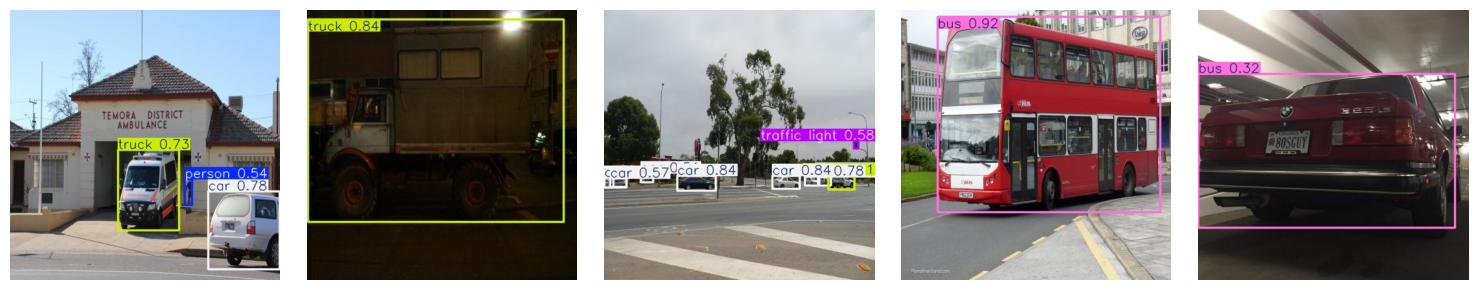

In [28]:


DATA_YAML = 'dataset/dataset.yaml'
TEST_IMAGES_DIR = Path('dataset/test/images')
SAMPLE_COUNT = 5

all_test_images = sorted(TEST_IMAGES_DIR.glob('*.jpg'))
sample_images = random.sample(all_test_images, k=min(SAMPLE_COUNT, len(all_test_images)))

pred = pretrained_model.predict(
    source=[str(p) for p in sample_images],
    conf=0.25,
    save=True,
    save_txt=False,
    imgsz=640,
    project='runs',
    name='pretrained_pred',
    exist_ok=True,
)

save_dir = Path(pred[0].save_dir)
files = sorted(save_dir.glob('*.jpg'))[:SAMPLE_COUNT]

if files:
    n = len(files)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1:
        axes = [axes]
    for ax, fp in zip(axes, files):
        ax.imshow(Image.open(fp))
        ax.axis('off')
    plt.tight_layout()
    plt.show()


### Оценка качества до дообучения

In [34]:
pre_val_results = pretrained_model.val(data=DATA_YAML, split='val', imgsz=640, plots=True)

pre_map = {
    'mAP@0.5': float(getattr(pre_val_results.box, 'map50', float('nan'))),
    'mAP@0.75': float(getattr(pre_val_results.box, 'map75', float('nan'))),
    'mAP@0.5:0.95': float(getattr(pre_val_results.box, 'map', float('nan'))),
}

with open('pretrained_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(pre_map, f, ensure_ascii=False, indent=2)

pre_map


Ultralytics 8.3.221  Python-3.11.9 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 5070, 12227MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 421.7108.1 MB/s, size: 32.1 KB)
val: Scanning D:\Stud\3sem\dl\lab1\dataset\valid\labels.cache... 250 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 250/250 250.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 8.5it/s 1.9s<0.2s
                   all        250        454      0.422      0.257      0.241      0.172
                person         50         64          0          0   7.95e-05   4.77e-05
               bicycle         30         46          0          0          0          0
                   car         90        238      0.511      0.546       0.48      0.334
            motorcycle         42         46      0.599      0.739       0.69      0.499
              airpla

{'mAP@0.5': 0.24070206916017178,
 'mAP@0.75': 0.20915807779711804,
 'mAP@0.5:0.95': 0.1723818387363319}

### Fine-tuning YOLOv8n на кастомном датасете
Запускаем обучение на `train/valid` из `dataset`.


In [35]:
EPOCHS = 30
BATCH = 16

train_results = trained_model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=640,
    batch=BATCH,
    device='auto',
    project='runs',
    name='yolov8n_finetune',
    exist_ok=True,
)

New https://pypi.org/project/ultralytics/8.3.226 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.221  Python-3.11.9 torch-2.8.0+cu129 CUDA:auto (NVIDIA GeForce RTX 5070, 12227MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/dataset.yaml, degrees=0.0, deterministic=True, device=auto, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_finetune, nbs=64, nms=

### Оценка качества после дообучения


In [36]:
post_val_results = trained_model.val(data=DATA_YAML, split='val', imgsz=640, plots=True)
post_metrics_full = post_val_results

post_map = {
    'mAP@0.5': float(getattr(post_val_results.box, 'map50', float('nan'))),
    'mAP@0.75': float(getattr(post_val_results.box, 'map75', float('nan'))),
    'mAP@0.5:0.95': float(getattr(post_val_results.box, 'map', float('nan'))),
}

with open('finetuned_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(post_map, f, ensure_ascii=False, indent=2)

post_map


Ultralytics 8.3.221  Python-3.11.9 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 5070, 12227MiB)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 367.8296.6 MB/s, size: 31.0 KB)
val: Scanning D:\Stud\3sem\dl\lab1\dataset\valid\labels.cache... 250 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 250/250 249.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 9.4it/s 1.7s<0.2s
                   all        250        454      0.718      0.532      0.588      0.432
             ambulance         50         64      0.777      0.875       0.88       0.75
                   bus         30         46      0.748      0.652      0.615      0.454
                   car         90        238      0.707      0.353      0.497      0.336
            motorcycle         42         46      0.652      0.348      0.464      0.276
                 truck

{'mAP@0.5': 0.5882746886771701,
 'mAP@0.75': 0.5112743336571139,
 'mAP@0.5:0.95': 0.43243085314600216}

### Сравнение метрик

In [37]:
with open('pretrained_metrics.json', 'r', encoding='utf-8') as f:
    pre_map = json.load(f)
with open('finetuned_metrics.json', 'r', encoding='utf-8') as f:
    post_map = json.load(f)

metrics_order = ['mAP@0.5', 'mAP@0.75', 'mAP@0.5:0.95']
df = pd.DataFrame({
    'Metric': metrics_order,
    'Pretrained': [pre_map[m] for m in metrics_order],
    'Fine-tuned': [post_map[m] for m in metrics_order],
})

df


,Metric,Pretrained,Fine-tuned
0,mAP@0.5,0.240702,0.588275
1,mAP@0.75,0.209158,0.511274
2,mAP@0.5:0.95,0.172382,0.432431


### Визуализация до и после (side-by-side)
Сверху до дообучения, снизу после


0: 640x640 1 bus, 15.3ms
1: 640x640 1 car, 15.3ms
2: 640x640 1 ambulance, 1 car, 15.3ms
3: 640x640 1 truck, 15.3ms
4: 640x640 5 cars, 15.3ms
Speed: 3.6ms preprocess, 15.3ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\Stud\3sem\dl\lab1\runs\trained_pred


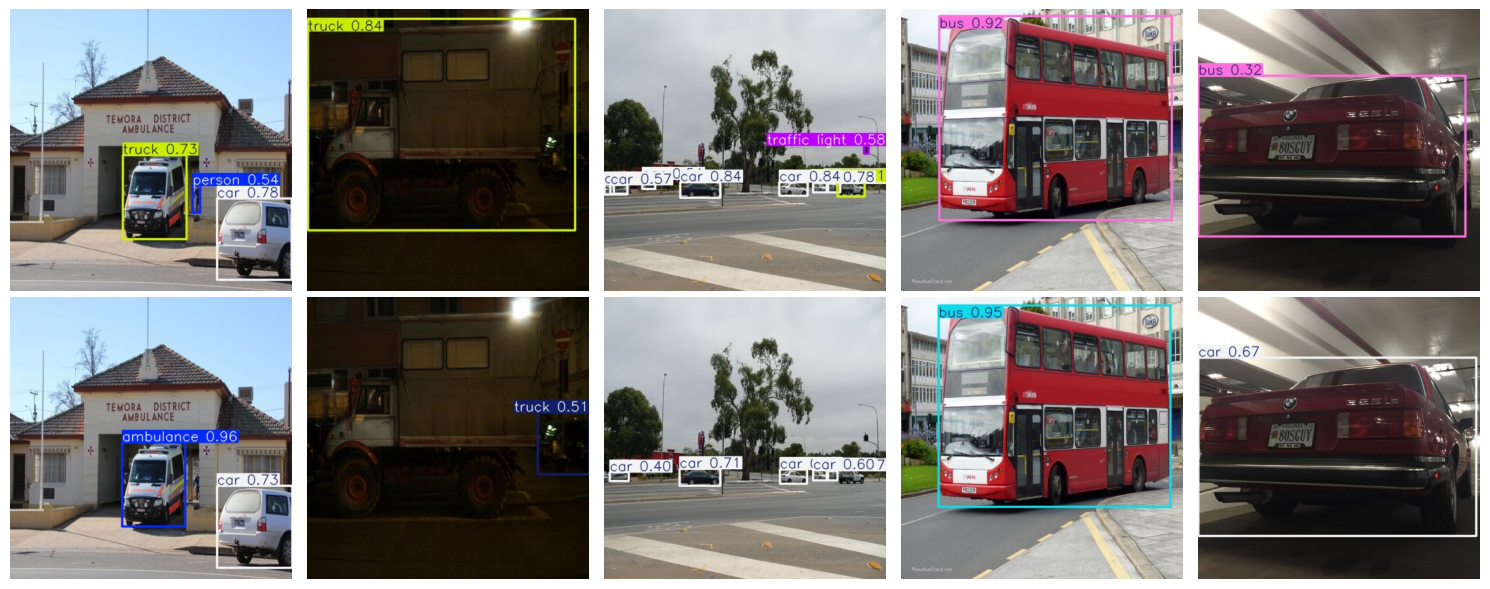

In [29]:
trained_pred = trained_model.predict(
    source=[str(p) for p in sample_images],
    conf=0.25,
    save=True,
    save_txt=False,
    imgsz=640,
    project='runs',
    name='trained_pred',
    exist_ok=True,
)

trained_save_dir = Path(trained_pred[0].save_dir)
trained_files = sorted(trained_save_dir.glob('*.jpg'))[:SAMPLE_COUNT]

if files and trained_files:
    n = min(len(files), len(trained_files))
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    if n == 1:
        axes = axes.reshape(2, 1)
    for j in range(n):
        axes[0, j].imshow(Image.open(files[j]))
        axes[0, j].axis('off')
        axes[1, j].imshow(Image.open(trained_files[j]))
        axes[1, j].axis('off')
    axes[0, 0].set_ylabel('До', fontsize=10)
    axes[1, 0].set_ylabel('После', fontsize=10)
    plt.tight_layout()
    plt.show()